In [16]:
import pandas as pd

from google.colab import drive
drive.mount("/content/drive")

data = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/2. Travel_Plan_Data.xlsx", sheet_name=0) ## Hoja 1
score = pd.read_excel("/content/drive/MyDrive/Colab Notebooks/2. Travel_Plan_Data.xlsx", sheet_name=1) ## Hoja 2

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [17]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     200 non-null    object 
 1   CreditCard  200 non-null    object 
 2   FoodSpend   200 non-null    float64
 3   Income      200 non-null    int64  
 4   TravelPlan  200 non-null    int64  
dtypes: float64(1), int64(2), object(2)
memory usage: 7.9+ KB


In [18]:
score.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   College     2 non-null      object 
 1   CreditCard  2 non-null      object 
 2   FoodSpend   2 non-null      float64
 3   Income      2 non-null      int64  
dtypes: float64(1), int64(1), object(2)
memory usage: 192.0+ bytes


## Intercambiamos los "Yes" y los "No" por 1 y 0 respectivamente

In [38]:
data['College'] = data['College'].replace({'Yes': 1, 'No': 0})
data['CreditCard'] = data['CreditCard'].replace({'Yes': 1, 'No': 0})
score['College'] = score['College'].replace({'Yes': 1, 'No': 0})
score['CreditCard'] = score['CreditCard'].replace({'Yes': 1, 'No': 0})
print (data)

     College  CreditCard  FoodSpend  Income  TravelPlan
0          0           0    2905.97   65982           1
1          1           0    4677.03   57274           1
2          0           0    5068.53   58520           1
3          0           1    4252.09   47330           0
4          0           0    6438.27   54422           1
..       ...         ...        ...     ...         ...
195        0           1    3405.75   46050           0
196        0           0    2892.90   65982           1
197        0           0    9129.66   59676           1
198        1           1    5550.56   47806           0
199        0           0    1892.37   77626           0

[200 rows x 5 columns]


## Hacemos el Split

In [39]:
XD = data[["College","CreditCard","FoodSpend","Income"]]
yd=data[["TravelPlan"]]

In [40]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import confusion_matrix

## Entrenamos el modelo


In [26]:
DTModel = DecisionTreeClassifier(criterion= "gini", max_depth=4)

DTModel.fit(XD, yd)

DecisionTreeClassifier(max_depth=4)

In [41]:
ydPred=DTModel.predict(XD)

In [42]:
cm= confusion_matrix(yd,ydPred)
cm

array([[105,  16],
       [ 31,  48]])

In [31]:
VN= cm[0,0];FP=cm[0,1];FN=cm[1,0];VP=cm[1,1]

In [32]:
### EXACTITUD (Accuracy): Es la proporción de predicciones correctas realizadas por el modelo sobre el total de predicciones.
print(f"La exatcitud del modelo es del {(cm[1][1]+cm[0][0])/cm.sum():.2%}")

La exatcitud del modelo es del 76.50%


In [33]:
## Tasa de error: Es el complemento de la exactitud. Representa la proporción de predicciones incorrectas.
print(f"La tasa de error del modelo es del {1 - (cm[1][1]+cm[0][0])/cm.sum():.2%}")

La tasa de error del modelo es del 23.50%


In [34]:
## Precisión: De las predicciones positivas realizadas por el modelo, ¿qué proporción fue realmente positiva?
cm[1][1]/(cm[1][1]+cm[0][1])
print(f"La precisión del modelo es del {cm[1][1]/(cm[1][1]+cm[0][1]):.2%}")

La precisión del modelo es del 75.00%


In [35]:
## Sensibilidad (o exhaustividad o recall): De todas las instancias positivas reales, ¿cuántas fueron correctamente identificadas por el modelo?
cm[1][1]/(cm[1][1]+cm[1][0])
print(f"La sensibilidad del modelo es del {cm[1][1]/(cm[1][1]+cm[1][0]):.2%}")

La sensibilidad del modelo es del 60.76%


In [36]:
## Especificidad: De todas las instancias negativas reales, ¿cuántas fueron correctamente identificadas por el modelo?
cm[0][0]/(cm[0][0]+cm[0][1])
print(f"La especificidad del modelo es del {cm[0][0]/(cm[0][0]+cm[0][1]):.2%}")

La especificidad del modelo es del 86.78%


## Hago el pronóstico para valores nuevos

In [43]:
ydGener = DTModel.predict(score)
ydGener

array([0, 0])

## Grafico el árbol

> Agregar bloque entrecomillado



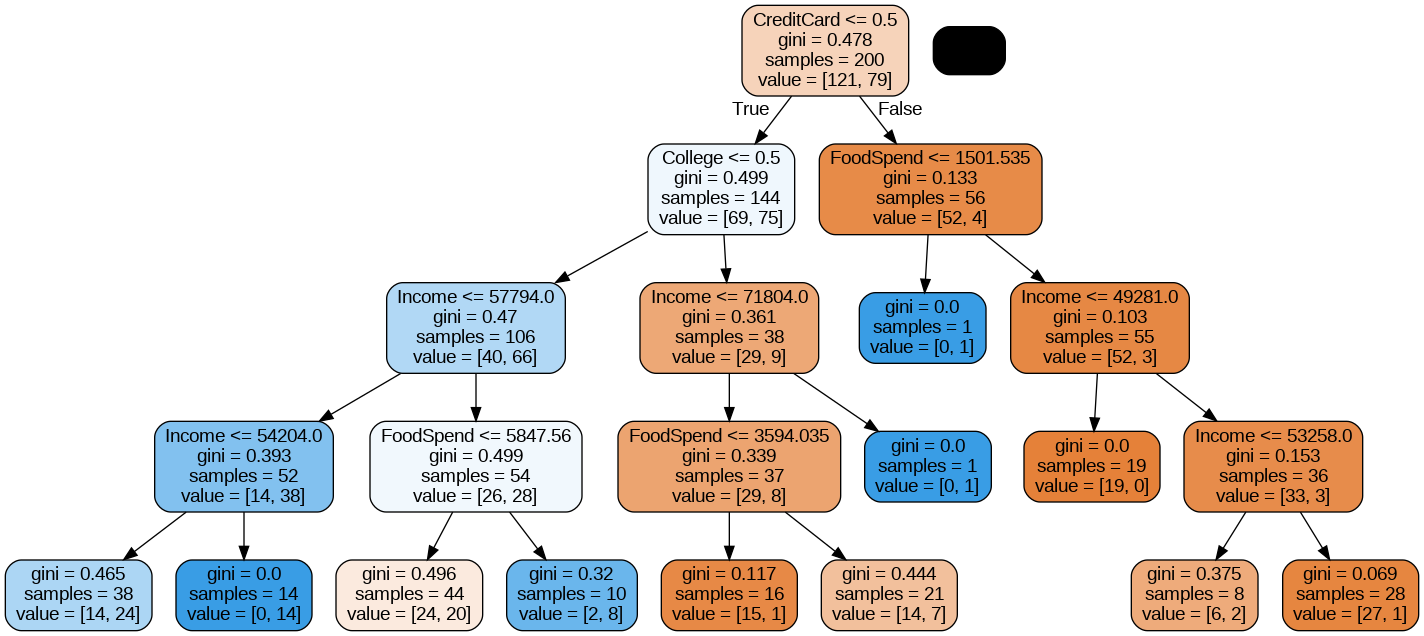

In [44]:
from sklearn.tree import export_graphviz
from pydotplus import graph_from_dot_data
from IPython.display import Image
from six import StringIO
import pydotplus

var = ["College","CreditCard","FoodSpend","Income"]
dot_data = StringIO()

export_graphviz(DTModel, out_file=dot_data,feature_names=var,filled=True,rounded=True)
graph = pydotplus.graph_from_dot_data(dot_data.getvalue())
Image(graph.create_png())

#Nodos Puros
#1. IF CreditCard>0.5 AND FoodSpend<=1501.535 THEN
### Prob viaje = 0%
### Prob no viaje = 100%
#2. IF CreditCard>0.5 AND FoodSpend > 1501.535 AND Income <=49281 THEN
### Prob viaje = 100%
### Prob no viaje = 0%
#3. IF CreditCard<=0.5 AND College<=0.5  AND Income <=71804 THEN
### Prob viaje = 0%
### Prob no viaje = 100%
#4. IF CreditCard<= 0.5 AND College<= 0.5  AND Income <=57794 AND Income > 54204 THEN
### Prob viaje = 0%
### Prob no viaje = 100%

# Reglas nuevos clientes

#1. IF CreditCard > 0.5 AND FoodSpend > 1501.535 AND Income > 53258 Then

### Prob viaje = 27/28 = 96.42%
### Prob no viaje = 1/28 = 3.58%

#2. IF CreditCard <= 0.5 AND College > 0.5 AND Income <= 71804 AND FoodSpend > 3594.035 THEN

### Prob viaje = 14/21 = 66.66%%
### Prob no viaje = 7/21 = 33.33%

# En conclusión, podemos decir que lo más probable es que el primer cliente si viaje y que el segundo tiene una mayor probabilidad de viajar pero no es tan seguro que vaya a hacerlo